**Experiment 4: Demonstrate the process of the Decision Tree construction for classification problems using python
programming.**

**Aim:** To demonstrate the construction of a Decision Tree classifier using Python and to identify the best-performing decision tree model by tuning hyperparameters, applying pruning techniques, and analyzing overfitting and underfitting, using two benchmark datasets.

**Overview of Decision Tree**

A **Decision Tree** is a **supervised learning algorithm** used for **classification and regression**.
It splits the dataset into subsets based on feature values, forming a tree-like structure of **nodes** and **branches**.

* **Root Node** – represents the entire dataset and the first feature split.
* **Internal Nodes** – represent features used for splitting.
* **Leaf Nodes** – represent the final prediction (class label or regression value).

Decision Trees make decisions by following paths from the root to a leaf node based on **feature conditions**.


**Key Concepts & Formulas**

**1. Entropy (Measure of Impurity)**

Entropy(S) = - Σ (p_i * log2(p_i))

Where p_i = probability of class i in the subset S.


**2. Information Gain (Best Split Criterion)**

Information Gain = Entropy(parent) - Σ (|S_v| / |S| * Entropy(S_v))

Where S_v = subset after splitting on a feature.


**3. Gini Index (Alternative Impurity Measure)**

Gini(S) = 1 - Σ (p_i^2)

Lower Gini → better split.

**4. Decision Rule**

At each node, choose the feature and threshold that **maximizes Information Gain** (or minimizes Gini).


**5. Final Prediction**

* **Classification:** class with majority in leaf node.
* **Regression:** average of target values in leaf node.


**Dataset Loading and Inspection**

We load the Iris dataset from a CSV file and inspect its structure.

In [77]:
import pandas as pd

iris_data = pd.read_csv('drive/MyDrive/Datasets For ML/Iris.csv')

print("Columns:", iris_data.columns)
print("\nShape:", iris_data.shape)
print("\nDuplicated Rows:", iris_data.duplicated().sum())
print("\nNull Values:", iris_data.isna().sum().sum())
print("\nFirst 2 rows:")
iris_data.head(2)

Columns: Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Shape: (150, 6)

Duplicated Rows: 0

Null Values: 0

First 2 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


**Dropping Irrelevant Column**

The Id column does not contribute to prediction and is removed.

In [78]:
iris_data.drop('Id', axis=1, inplace=True)
iris_data.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


**Feature–Label Separation**

X → Feature matrix

Y → Target labels

In [79]:
X, Y = iris_data.iloc[:, :-1], iris_data.iloc[:, -1]

**Note:**
Decision Trees can directly handle categorical labels, so label encoding is NOT required here.

**Train–Test Split**

Stratified split ensures equal class distribution

Default split: 75% training, 25% testing

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, random_state=5)

print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (112, 4)
X_test Shape:  (38, 4)


**Baseline Decision Tree (No Constraints → Overfitting Risk)**

In [81]:
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(random_state=5)
dt_base.fit(X_train, Y_train)

print("Train Accuracy:", dt_base.score(X_train, Y_train))
print("Test Accuracy:", dt_base.score(X_test, Y_test))

Train Accuracy: 1.0
Test Accuracy: 0.8947368421052632


**Observation:**

The gap between training accuracy (100%) and test accuracy (~89%) confirms that the unconstrained Decision Tree is overfitting.


To improve generalization, the tree must be regularized using parameters such as max_depth, min_samples_leaf, min_samples_split, or by applying cost-complexity pruning (ccp_alpha).

**Effect of Tree Depth (Bias–Variance Tradeoff)**

In [82]:
train_acc = []
test_acc = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=5)
    model.fit(X_train, Y_train)
    train_acc.append(model.score(X_train, Y_train))
    test_acc.append(model.score(X_test, Y_test))

print("Train Accuracies:", train_acc)
print("Test Accuracies:", test_acc)

Train Accuracies: [0.6696428571428571, 0.9732142857142857, 0.9821428571428571, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Test Accuracies: [0.6578947368421053, 0.9210526315789473, 0.9736842105263158, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632]


**Accuracy vs Depth Plot**

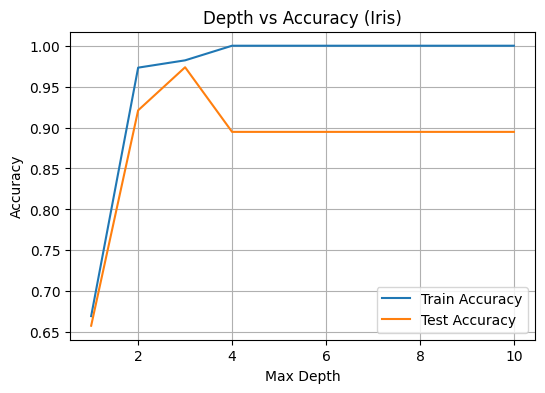

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1,11), train_acc, label='Train Accuracy')
plt.plot(range(1,11), test_acc, label='Test Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy (Iris)")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**

**1. Small Depth → Underfitting (Depth = 1)**

Both train and test accuracies are low

Model is too simple to capture class boundaries

Indicates high bias

**Conclusion:** Underfitting occurs at low depth


**2. Medium Depth → Best Generalization (Depth = 3)**

Training accuracy ≈ 98.2%

Testing accuracy ≈ 97.4% (maximum)

Very small gap between train and test accuracy

**Conclusion:** Depth = 3 provides the best bias–variance tradeoff

**3. Large Depth → Overfitting (Depth ≥ 4)**

Training accuracy = 100%

Testing accuracy drops to ~89.5%

Model memorizes training data

Generalization degrades

**Conclusion:** Increasing depth beyond 3 causes overfitting

**Conclusion:**

From the experimental results, it is observed that a decision tree with max_depth = 3 achieves the highest test accuracy (97.36%) with minimal difference between training and testing accuracy. Hence, depth 3 is selected as the optimal depth, as lower depths underfit the data and higher depths overfit.

**Criterion Comparison**

In [84]:
criteria = ['gini', 'entropy', 'log_loss']
for c in criteria:
    model = DecisionTreeClassifier(
        criterion=c, max_depth=3, random_state=5
    )
    model.fit(X_train, Y_train)
    print(c, "Accuracy:", model.score(X_test, Y_test))

gini Accuracy: 0.9736842105263158
entropy Accuracy: 0.9736842105263158
log_loss Accuracy: 0.9736842105263158


**Observation / Conclusion**

All three splitting criteria—**Gini**, **Entropy**, and **Log Loss**—produce the **same classification accuracy (≈ 97.37%)** on the Iris test dataset when the tree depth is fixed at 3.

This indicates that:

* The **Iris dataset is simple, clean, and well-separated**, so different impurity measures lead to **similar optimal splits**.
* For such datasets, **choice of criterion has minimal impact** on performance.
* **Tree depth and pruning parameters influence accuracy more than the splitting criterion**.

**Conclusion:**
For small, low-noise datasets like Iris, **any of the three criteria can be safely used**, and model performance is primarily controlled by **tree complexity rather than impurity measure selection**.


**Cost Complexity Pruning (Best Practice)**

In [85]:
path = dt_base.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

acc = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=5, ccp_alpha=alpha
    )
    model.fit(X_train, Y_train)
    acc.append(model.score(X_test, Y_test))

print("Test Accuracy:", acc)

Test Accuracy: [0.8947368421052632, 0.9210526315789473, 0.9736842105263158, 0.9210526315789473, 0.6578947368421053, 0.3157894736842105]


**Alpha vs Accuracy Plot**

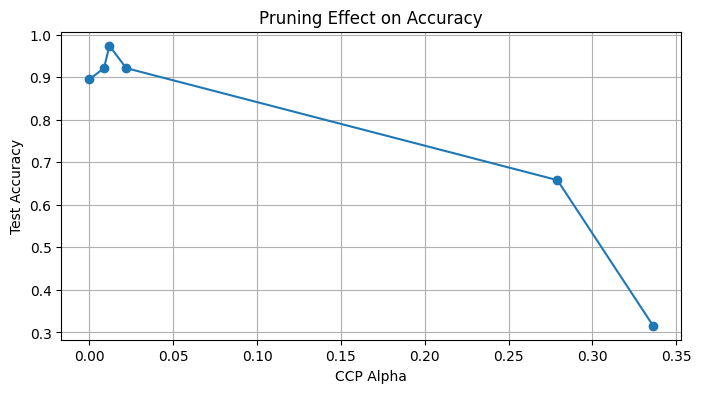

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, acc, marker='o')
plt.xlabel("CCP Alpha")
plt.ylabel("Test Accuracy")
plt.title("Pruning Effect on Accuracy")
plt.grid(True)
plt.show()

**Observation / Conclusion (Cost-Complexity Pruning):**

* As **ccp_alpha increases**, the decision tree becomes **simpler** due to stronger pruning.
* **Moderate pruning** improves generalization:

  * Test accuracy increases from **0.89 → 0.97**, indicating **reduction of overfitting**.
* The **best performance (≈97.37%)** occurs at an **optimal intermediate ccp_alpha**, where the tree balances bias and variance.
* **Excessive pruning** (larger ccp_alpha values) causes a sharp drop in accuracy (**0.65 → 0.31**), indicating **underfitting**.

**Final Conclusion:**
Cost-complexity pruning is effective for controlling overfitting in decision trees. An **optimal ccp_alpha value yields the best generalization**, while too little or too much pruning degrades performance.


**Final Best Model (Iris)**

In [87]:
best_alpha = ccp_alphas[acc.index(max(acc))]

best_dt_iris = DecisionTreeClassifier(
    max_depth=3,
    criterion='gini',
    ccp_alpha=best_alpha,
    random_state=5
)
best_dt_iris.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.011904761904761904), max_depth=3,
                       random_state=5)

**Decision Tree Visualization**

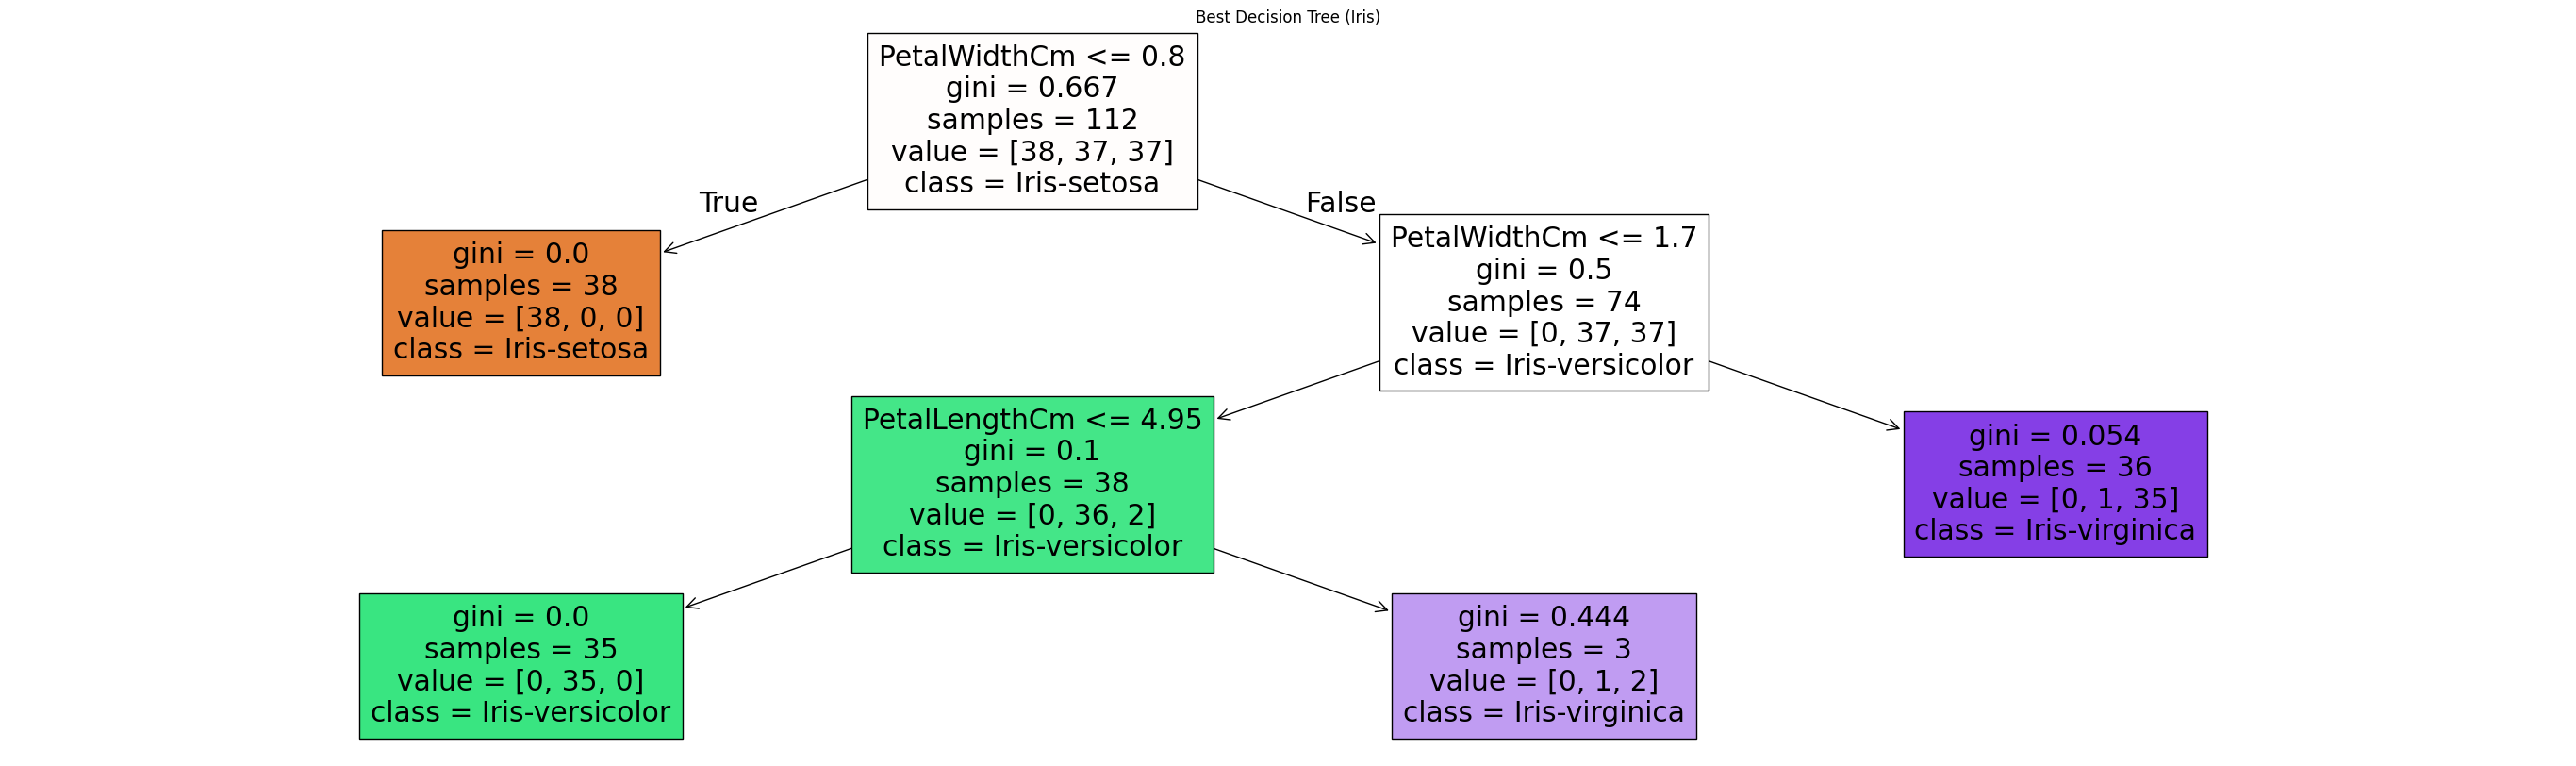

In [88]:
from sklearn.tree import plot_tree
plt.figure(figsize=(35, 10))
plot_tree(
    best_dt_iris,
    feature_names=X.columns,
    class_names=best_dt_iris.classes_,
    filled=True
)
plt.title("Best Decision Tree (Iris)")
plt.show()

**Methods and Model Inspection Utilities of DecisionTreeClassifier**

These are built-in methods of the DecisionTreeClassifier used for prediction, evaluation, and structural inspection of the trained decision tree model.

Returns the leaf node index where each test sample ends up in the decision tree.

Helps understand which final decision rule classified each sample.

In [89]:
best_dt_iris.apply(X_test, check_input=True)

array([1, 1, 5, 1, 6, 1, 4, 1, 6, 4, 4, 6, 6, 1, 4, 6, 4, 6, 4, 4, 6, 1,
       4, 1, 1, 6, 4, 4, 1, 6, 6, 5, 1, 4, 6, 6, 1, 4])

Returns the path of nodes (root → leaf) followed by each sample.

Useful for interpreting how decisions are made step by step.

In [90]:
best_dt_iris.decision_path(X_test, check_input=True)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 116 stored elements and shape (38, 7)>

Returns the maximum depth of the trained decision tree.

Indicates model complexity and helps detect overfitting.

In [91]:
best_dt_iris.get_depth()

3

Shows how metadata (like sample weights) is routed through the estimator.

Mainly for advanced pipelines and meta-estimators.

In [92]:
best_dt_iris.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

Returns the total number of leaf nodes in the tree.

Higher number of leaves generally means more complex model.

In [93]:
best_dt_iris.get_n_leaves()

np.int64(4)

Returns all hyperparameters used to create the decision tree.

Important for model reproducibility and tuning.

In [94]:
best_dt_iris.get_params()

{'ccp_alpha': np.float64(0.011904761904761904),
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 5,
 'splitter': 'best'}

Predicts the class labels for the test samples.

Final output of the classifier.

In [95]:
best_dt_iris.predict(X_test)

array(['Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor'], dtype=object)

Returns the logarithm of predicted class probabilities.

Numerically stable form of probabilities for advanced analysis.

In [96]:
best_dt_iris.predict_log_proba(X_test)[:5]

/usr/local/lib/python3.12/dist-packages/sklearn/tree/_classes.py:1089: RuntimeWarning: divide by zero encountered in log
  return np.log(proba)


array([[ 0.        ,        -inf,        -inf],
       [ 0.        ,        -inf,        -inf],
       [       -inf, -1.09861229, -0.40546511],
       [ 0.        ,        -inf,        -inf],
       [       -inf, -3.58351894, -0.02817088]])

Returns the probability distribution over all classes for each sample.

Used for confidence estimation and threshold-based decisions.

In [97]:
best_dt_iris.predict_proba(X_test)[:5]

array([[1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 0.33333333, 0.66666667],
       [1.        , 0.        , 0.        ],
       [0.        , 0.02777778, 0.97222222]])

Returns the classification accuracy on the test dataset.

Quick performance evaluation metric.

In [98]:
best_dt_iris.score(X_test, Y_test)

0.9736842105263158

**Performance Evaluation**

In [99]:
from sklearn import metrics

Y_pred = best_dt_iris.predict(X_test)

print("Classification Report:\n", metrics.classification_report(Y_test, Y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(Y_test, Y_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38

Confusion Matrix:
 [[12  0  0]
 [ 0 12  1]
 [ 0  0 13]]


**Conclusion**

A Decision Tree is a powerful and easy-to-understand tool for classification. By adjusting settings like max_depth and ccp_alpha, we can stop the model from simply memorizing data (overfitting) or being too simple (underfitting). In this experiment, a tree depth of 3 provided the perfect balance, giving the highest accuracy on new data.